This notebook scrapes data from yfinance, using the NumPy, pandas, and scipy libraries computes descriptive statistics and the four moments.

We begin by using yf.download to call the adjusted closing prices of the given securities. We use SPY instead of ^GSPC because SPY is actually tradeable.


In [29]:
import pandas as pd
import numpy as np
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import norm
import matplotlib.pyplot as plt

## Return Definitions
Simple returns are intuitive and used for interpretation and reporting.<br>

Log returns are additive over time and more convenient for modelling and statistical analysis.
Both are computed here to compare their behaviour on daily equity data.

In [30]:
#import yfinance for data
import yfinance as yf
secs = ['AAPL', 'SAIL.NS', 'MSFT', 'RELIANCE.NS', 'SPY'] #define securities in a list
data = yf.download(secs, start='2016-01-01', end='2026-01-01', auto_adjust=False) #download data within time frame, auto_adjust false
#means adj close is available separately, otherwise OHLC is adjusted by default
adj_close = data['Adj Close'].dropna() #defining adjusted close and dropna removes N/A entries

returns = adj_close.pct_change().dropna() #computing returns cause prices are usless and dropna removes N/A entries
log_returns = np.log(adj_close).diff().dropna() #computing log returns
print(returns.head())
print(log_returns.head())

[*********************100%***********************]  5 of 5 completed

Ticker          AAPL      MSFT  RELIANCE.NS   SAIL.NS       SPY
Date                                                           
2016-01-05 -0.025059  0.004562     0.009897  0.064718  0.001691
2016-01-06 -0.019570 -0.018166     0.026912 -0.019608 -0.012614
2016-01-07 -0.042204 -0.034782    -0.018359 -0.069000 -0.023991
2016-01-08  0.005288  0.003067     0.012337  0.018260 -0.010977
2016-01-11  0.016192 -0.000574     0.025201 -0.020042  0.000990
Ticker          AAPL      MSFT  RELIANCE.NS   SAIL.NS       SPY
Date                                                           
2016-01-05 -0.025378  0.004552     0.009848  0.062710  0.001690
2016-01-06 -0.019764 -0.018333     0.026556 -0.019803 -0.012695
2016-01-07 -0.043121 -0.035402    -0.018530 -0.071496 -0.024284
2016-01-08  0.005274  0.003062     0.012261  0.018095 -0.011037
2016-01-11  0.016062 -0.000574     0.024889 -0.020245  0.000989


From the prices, we compute simple returns. Analysis of returns leads to data that can be studied. Direct analysis of prices would lead to nonsensical results. We compute descriptive statistics for each asset seprately.

In [31]:
# Now calculate statistics PER ASSET (column-wise).
print("=== Means (Annualised Daily Return) ===")
print(returns.mean()*252)
print(log_returns.mean()*252)
mean = returns.mean()*252
mean2 = log_returns.mean()*252
print("\n=== Standard Deviation (Annualised Daily Volatility) ===") # \n is like text break
std = returns.std()*np.sqrt(252)
std2 = log_returns.std()*np.sqrt(252)
print(returns.std()*np.sqrt(252))
risk_free_rate = 0.02  # 2% annual

# Skew and Kurtosis
print("\n=== Skewness ===")
print(returns.skew())
print("\n=== Kurtosis (Excess) ===")
print(returns.kurtosis())

=== Means (Annualised Daily Return) ===
Ticker
AAPL           0.300898
MSFT           0.280901
RELIANCE.NS    0.246470
SAIL.NS        0.238162
SPY            0.162763
dtype: float64
Ticker
AAPL           0.256908
MSFT           0.243510
RELIANCE.NS    0.209247
SAIL.NS        0.137107
SPY            0.146175
dtype: float64

=== Standard Deviation (Annualised Daily Volatility) ===
Ticker
AAPL           0.296413
MSFT           0.273108
RELIANCE.NS    0.273140
SAIL.NS        0.449830
SPY            0.181682
dtype: float64

=== Skewness ===
Ticker
AAPL           0.128316
MSFT           0.047966
RELIANCE.NS    0.416787
SAIL.NS        0.145826
SPY           -0.314042
dtype: float64

=== Kurtosis (Excess) ===
Ticker
AAPL            6.649545
MSFT            7.818273
RELIANCE.NS     9.106355
SAIL.NS         3.878059
SPY            14.681503
dtype: float64


Plotting Sharpe ratios, means, and standard deviations

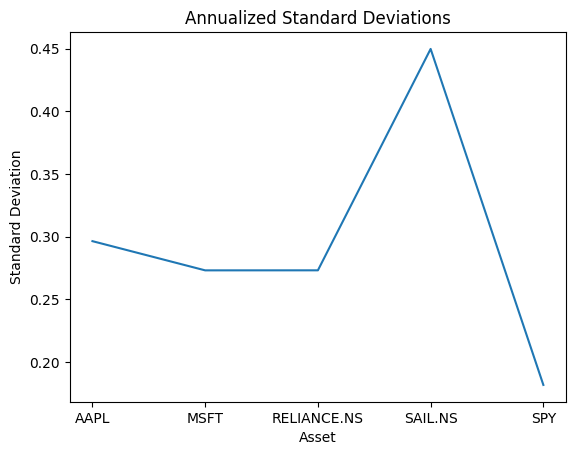

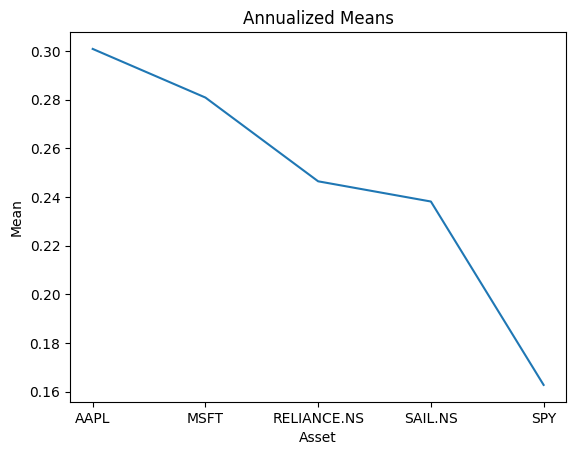

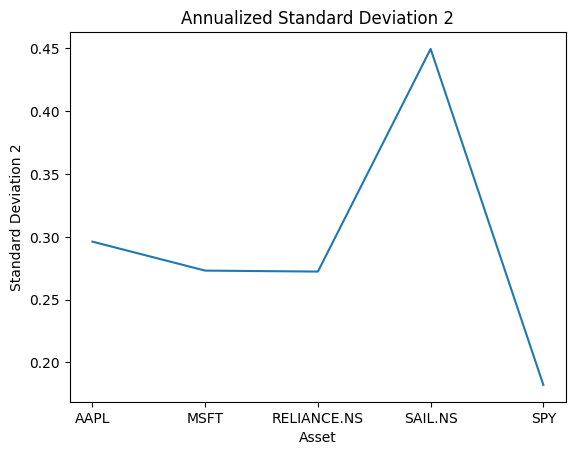

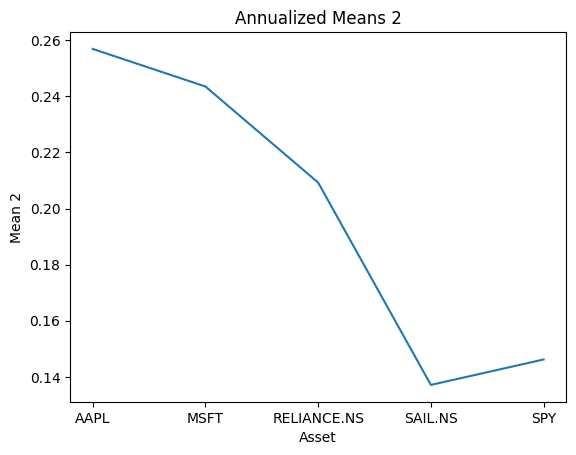

In [32]:
plt.plot(std)
plt.title('Annualized Standard Deviations')
plt.xlabel('Asset')
plt.ylabel('Standard Deviation')
plt.show()

plt.plot(mean)
plt.title('Annualized Means')
plt.xlabel('Asset')
plt.ylabel('Mean')
plt.show()

plt.plot(std2)
plt.title('Annualized Standard Deviation 2')
plt.xlabel('Asset')
plt.ylabel('Standard Deviation 2')
plt.show()

plt.plot(mean2)
plt.title('Annualized Means 2')
plt.xlabel('Asset')
plt.ylabel('Mean 2')
plt.show()

Now, we use a correlation matrix to study dependencies across our porfolio. First, we compute a returns correlation matrix. Then we compute annualised volatilities and finally, annualised covariance matrix.

In [33]:
# Correlation matrix (from daily returns)
corr_matrix = returns.corr()
cr_mat = log_returns.corr()
print("Correlation Matrix (Daily):")
print(corr_matrix.round(3))
print("Correlation Matrix Log Returns (Daily):")
print(cr_mat.round(3))

Correlation Matrix (Daily):
Ticker        AAPL   MSFT  RELIANCE.NS  SAIL.NS    SPY
Ticker                                                
AAPL         1.000  0.660        0.112    0.123  0.741
MSFT         0.660  1.000        0.123    0.118  0.790
RELIANCE.NS  0.112  0.123        1.000    0.324  0.202
SAIL.NS      0.123  0.118        0.324    1.000  0.198
SPY          0.741  0.790        0.202    0.198  1.000
Correlation Matrix Log Returns (Daily):
Ticker        AAPL   MSFT  RELIANCE.NS  SAIL.NS    SPY
Ticker                                                
AAPL         1.000  0.662        0.115    0.124  0.742
MSFT         0.662  1.000        0.126    0.117  0.791
RELIANCE.NS  0.115  0.126        1.000    0.331  0.206
SAIL.NS      0.124  0.117        0.331    1.000  0.200
SPY          0.742  0.791        0.206    0.200  1.000


In [34]:
# Calculate annualized volatilities
annual_vols = returns.std() * np.sqrt(252)
annual_vols2 = log_returns.std() * np.sqrt(252)

# Correlation matrix (from daily returns)
corr_matrix = returns.corr()
corr_matrix2 = log_returns.corr()

# Build the annualized covariance matrix
# Σ_annual = Corr * (σ_i * σ_j) for all i,j
cov_matrix_annual = corr_matrix * np.outer(annual_vols, annual_vols) #computes the outer product of two vectors
cov_matrix_annual2 = corr_matrix2 * np.outer(annual_vols2, annual_vols2)

In [35]:
# Annualized covariance matrix: Corr * (std_i * std_j)
# We already have annualized volatilities (std_annual)
std_annual = returns.std() * np.sqrt(252)  # Check: should match earlier numbers
std_annual

,0
Ticker,
AAPL,0.296413
MSFT,0.273108
RELIANCE.NS,0.273140
SAIL.NS,0.449830
SPY,0.181682


In [36]:
std_annual2 = log_returns.std() * np.sqrt(252)  # check
std_annual2

,0
Ticker,
AAPL,0.296141
MSFT,0.273084
RELIANCE.NS,0.272327
SAIL.NS,0.449580
SPY,0.182082


In [37]:
# Build the covariance matrix manually to understand it:
cov_matrix_annual = np.outer(std_annual, std_annual) * corr_matrix
cov_matrix_annual2 = np.outer(std_annual2, std_annual2) * corr_matrix2

In [38]:
print("\nAnnualized Covariance Matrix 2:")
print(pd.DataFrame(cov_matrix_annual2, index=std_annual.index, columns=std_annual.index).round(6))


Annualized Covariance Matrix 2:
Ticker           AAPL      MSFT  RELIANCE.NS   SAIL.NS       SPY
Ticker                                                          
AAPL         0.087699  0.053529     0.009302  0.016483  0.039987
MSFT         0.053529  0.074575     0.009401  0.014389  0.039328
RELIANCE.NS  0.009302  0.009401     0.074162  0.040477  0.010239
SAIL.NS      0.016483  0.014389     0.040477  0.202122  0.016381
SPY          0.039987  0.039328     0.010239  0.016381  0.033154


Calculating beta and CAPM

In [39]:
# Beta & CAPM Expected Return
market_returns = returns['SPY']
market_returns2 = log_returns['SPY']
stock_returns = returns.drop(columns=['SPY'])
stock_log_returns = log_returns.drop(columns=['SPY'])
betas = {}
for stock in stock_returns.columns:
    cov = np.cov(stock_returns[stock], market_returns)[0,1]
    beta = cov / np.var(market_returns)
    betas[stock] = beta
    # Expected Return = Rf + beta * (Market Return - Rf)
    expected_return = risk_free_rate + beta * (market_returns.mean() * 252 - risk_free_rate)
    print(f"{stock}: Beta = {beta:.3f}, Exp Return = {expected_return:.2%}")

for stck in stock_log_returns:
    cov = np.cov(stock_log_returns[stck], market_returns2)[0,1]
    beta2 = cov / np.var(market_returns2)
    betas[stck] = beta2
    # Expected Return = Rf + beta * (Market Return - Rf)
    expected_return = risk_free_rate + beta2 * (market_returns2.mean() * 252 - risk_free_rate)
    print(f"{stck}: Beta = {beta2:.3f}, Exp Return = {expected_return:.2%}")

AAPL: Beta = 1.209, Exp Return = 19.25%
MSFT: Beta = 1.188, Exp Return = 18.96%
RELIANCE.NS: Beta = 0.304, Exp Return = 6.34%
SAIL.NS: Beta = 0.492, Exp Return = 9.02%
AAPL: Beta = 1.207, Exp Return = 17.22%
MSFT: Beta = 1.187, Exp Return = 16.97%
RELIANCE.NS: Beta = 0.309, Exp Return = 5.90%
SAIL.NS: Beta = 0.494, Exp Return = 8.24%


In [40]:
# Calculate annualized volatilities
annual_vols = returns.std() * np.sqrt(252)  # This is 'vols'

# Correlation matrix (from daily returns)
corr_matrix = returns.corr()

# Build the annualized covariance matrix
# Σ_annual = Corr * (σ_i * σ_j) for all i,j
cov_matrix_annual = corr_matrix * np.outer(annual_vols, annual_vols)
cov_matrix_annual

Ticker,AAPL,MSFT,RELIANCE.NS,SAIL.NS,SPY
Ticker,,,,,
AAPL,0.087861,0.053396,0.009072,0.016374,0.039878
MSFT,0.053396,0.074588,0.009151,0.014439,0.039199
RELIANCE.NS,0.009072,0.009151,0.074606,0.039761,0.010023
SAIL.NS,0.016374,0.014439,0.039761,0.202347,0.016222
SPY,0.039878,0.039199,0.010023,0.016222,0.033009


In [41]:
# check
print("AAPL annual vol:", std_annual['AAPL'])    # Should be 0.296
print("AAPL annual variance:", std_annual['AAPL']**2)   # Should be 0.0876
print("Cov matrix diagonal:", cov_matrix_annual.loc['AAPL', 'AAPL'])  # Should match

AAPL annual vol: 0.29641282355295095
AAPL annual variance: 0.08786056196663283
Cov matrix diagonal: 0.08786056196663283


In [42]:
# Verify shape and print a snippet
print("Covariance Matrix (annualized) shape:", cov_matrix_annual.shape)
print("\nDiagonal elements (should be variances, i.e., vol^2):")
for i, ticker in enumerate(returns.columns):
    # Use .iloc for integer-based indexing on the DataFrame
    print(f"{ticker}: {cov_matrix_annual.iloc[i, i]:.6f} ≈ {annual_vols[ticker]**2:.6f}")

Covariance Matrix (annualized) shape: (5, 5)

Diagonal elements (should be variances, i.e., vol^2):
AAPL: 0.087861 ≈ 0.087861
MSFT: 0.074588 ≈ 0.074588
RELIANCE.NS: 0.074606 ≈ 0.074606
SAIL.NS: 0.202347 ≈ 0.202347
SPY: 0.033009 ≈ 0.033009


In [43]:
# Define portfolio weights (equal-weight example)
assets = returns.columns.tolist()
weights = np.array([1/len(assets)] * len(assets))  # Equal weight

# Portfolio variance & volatility (annualised)
portfolio_variance = weights.T @ cov_matrix_annual @ weights
portfolio_vol = np.sqrt(portfolio_variance)

# Portfolio returns
portfolio_returns = returns @ weights

print(f"\nEqual-weight portfolio annual volatility: {portfolio_vol:.4f} ({portfolio_vol*100:.2f}%)")


Equal-weight portfolio annual volatility: 0.1967 (19.67%)


In [44]:
vol_values = [0.296413, 0.273108, 0.273140, 0.449830, 0.181682]
np.mean(vol_values)

np.float64(0.2948346)

The earlier individual volatilities were 0.2964, 0.2731, 0.2731, 0.4498, 0.1817, meaning average is 0.295, however, equal-weighted annual vol is 0.197. <br> <br> That is a 33.22% reduction in volatility. This can be expanded upon by utilising sharpe ratio for allocating weights with an ideal risk-return profile. However, this is omitted for the sake of simplicity.

# Computing Risk Metrics

In [77]:
# Now we compute VaR on our portfolio
# Regulatory market risk frameworks commonly require 10-day risk measures
# Therefore, 1-day VaR is scaled using the square-root-of-time rule.

alpha_var = 0.99
alpha_es  = 0.975

var_1d = np.percentile(portfolio_returns, (1 - alpha_var) * 100)
var_10d_loss = -var_1d*np.sqrt(10)
es_var_threshold = np.percentile(portfolio_returns, (1 - alpha_es) * 100)
tail_returns = portfolio_returns[portfolio_returns <= es_var_threshold]
es_10d_loss = -tail_returns.mean()*np.sqrt(10)

assert var_10d_loss > 0, "VaR loss must be positive"
assert es_10d_loss > 0, "ES loss must be positive"
assert es_10d_loss >= var_10d_loss, "ES should be greater than or equal to VaR"

In [78]:
print(f"10-day {alpha_var*100: .0f}% Historical VaR: {var_10d_loss:.2%}")
print(f"10-day {alpha_es*100:.1f}% Historical ES: {es_10d_loss:.2%}")

10-day  99% Historical VaR: 10.27%
10-day 97.5% Historical ES: 11.32%


In [67]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
z_var = norm.ppf(1 - alpha_var)
var_parametric_10d_loss = -(mu + sigma * z_var)*np.sqrt(10)

z_es = norm.ppf(1 - alpha_es)
es_parametric_10d_loss = (mu + sigma * norm.pdf(z_es) / (1 - alpha_es))*np.sqrt(10)

assert var_parametric_10d_loss > 0, "Parametric VaR must be positive"
assert es_parametric_10d_loss > 0, "Parametric ES must be positive"
assert es_parametric_10d_loss >= var_parametric_10d_loss, "ES must be >= VaR"

In [68]:
print(f"10-day {alpha_var*100: .0f}% Parametric VaR (Normal): {var_parametric_10d_loss:.2%}")
print(f"10-day {alpha_es*100}% Parametric ES (Normal): {es_parametric_10d_loss:.2%}")

10-day  99% Parametric VaR (Normal): 8.81%
10-day 97.5% Parametric ES (Normal): 9.47%


Parametric risk measures rely on distributional assumptions and may underestimate tail risk in the presence of skewness and excess kurtosis.<br><br>
Parametric ES increases more than √T due to tail sensitivity of φ(z)/(1−α) under the normal assumption

### Time Scaling of Parametric Expected Shortfall

While VaR and ES are often approximated as scaling with √T under
Gaussian i.i.d. assumptions, parametric ES does not scale exactly
by √T.

The Expected Shortfall formula is:

ES_α = μ + σ · φ(z_α) / (1 − α)

When scaling from 1 day to T days:

μ_T = Tμ  
σ_T = √T σ

Thus:

ES_T = Tμ + √T σ · φ(z_α) / (1 − α)

Unless μ = 0, the ratio ES_T / ES_1d is not exactly √T.
At high confidence levels, the ES tail factor amplifies this effect,
causing parametric ES to grow slightly faster than √T.

This explains why 10-day parametric ES exceeds the naive √10 scaling
of the 1-day ES.

# Backtesting

In [69]:
print(f"VaR threshold: {var_1d:.4f}")
print(f"Returns < -var: {(returns < -var_1d).sum()} / {len(returns)}")
print(f"Sample returns: {returns.iloc[:5].values.tolist()}")

VaR threshold: -0.0325
Returns < -var: Ticker
AAPL           2295
MSFT           2321
RELIANCE.NS    2315
SAIL.NS        2117
SPY            2377
dtype: int64 / 2391
Sample returns: [[-0.025059137110569285, 0.0045624162495261356, 0.00989652150810949, 0.064718195869504, 0.001691368922446257], [-0.019569718782262324, -0.018165511465801254, 0.0269115342022348, -0.01960803445753334, -0.012614269683023593], [-0.04220417845087132, -0.034782440798402314, -0.018358956788982583, -0.06899983299916423, -0.02399143952621463], [0.005287617230942621, 0.003066884908033529, 0.012336507756473214, 0.01825976584566713, -0.010976614365308834], [0.016191869456922303, -0.0005736686506562227, 0.02520111026417693, -0.020041926176988523, 0.0009899569974236577]]


In [70]:
print(f"VaR threshold value: {var_1d}")
print(f"Should be positive? {var_1d > 0}")
print(f"First 5 returns: {portfolio_returns.head().tolist()}")

VaR threshold value: -0.032478083966993504
Should be positive? False
First 5 returns: [0.011161873087803321, -0.008609200037277144, -0.037667369712727015, 0.005594832275161533, 0.004353468378175628]


In [71]:
from scipy.stats import chi2

def kupiec_pof_test(returns, var, alpha=0.01):
    """
    Kupiec's Proportion of Failures test.

    Tests whether the actual failure rate of a VaR model
    matches the expected failure rate (alpha).

    Parameters:
    - returns: array-like, portfolio returns
    - var: positive VaR threshold (e.g., 0.0174 for 1.74%)
    - alpha: expected failure rate (default 0.01 for 99% VaR)

    Returns:
    - Dictionary with test statistics and conclusion
    """
    n = len(returns)
    failures = np.sum(returns < -var)
    failure_rate = failures / n
    expected = n * alpha

    # Handle edge cases
    if failures == 0:
        LR = -2 * np.log((1 - alpha)**n)
    elif failures == n:
        LR = -2 * np.log(alpha**n)
    else:
        LR = -2 * np.log(
            ((1 - alpha)**(n - failures) * alpha**failures) /
            ((1 - failure_rate)**(n - failures) * failure_rate**failures)
        )

    critical_value = chi2.ppf(0.99, 1)
    p_value = 1 - chi2.cdf(LR, 1)

    return {
        'model': 'Historical' if var == hist_var_pos else 'Parametric',
        'var_level': f"{alpha*100:.0f}%",
        'failures': failures,
        'expected_failures': round(expected, 1),
        'failure_rate': f"{failure_rate:.2%}",
        'LR_statistic': round(LR, 4),
        'p_value': round(p_value, 4),
        'reject_H0': LR > critical_value,
        'critical_value': round(critical_value, 4)
    }

# Run tests
hist_var_pos = -var_1d
param_var_pos = var_parametric_10d_loss / np.sqrt(10)

hist_result = kupiec_pof_test(portfolio_returns, hist_var_pos)
param_result = kupiec_pof_test(portfolio_returns, param_var_pos)

# Display
import pandas as pd
results_df = pd.DataFrame([hist_result, param_result])
print(results_df[['model', 'var_level', 'failures', 'expected_failures',
                  'failure_rate', 'p_value', 'reject_H0']].to_string(index=False))

     model var_level  failures  expected_failures failure_rate  p_value  reject_H0
Historical        1%        24               23.9        1.00%   0.9853      False
Parametric        1%        39               23.9        1.63%   0.0045       True


### Backtesting VaR Models — Kupiec POF Test

To assess whether our VaR models are correctly calibrated, we apply Kupiec's Proportion of Failures (POF) test. The test evaluates whether the observed failure rate (returns exceeding the VaR threshold) matches the expected failure rate of 1% (for 99% VaR).

**Results:**

| Model | Failures | Expected | Failure Rate | p-value | Reject H₀? |
|-------|----------|----------|--------------|---------|------------|
| Historical VaR | 24 | 23.9 | 1.00% | 0.9853 | ❌ No |
| Parametric VaR | 39 | 23.9 | 1.63% | 0.0045 | ✅ Yes |

**Interpretation:**

The historical VaR model passes the Kupiec test (p = 0.9853), indicating it is well-calibrated to the empirical distribution of returns.

The parametric VaR model fails the test (p = 0.0045). With 39 exceptions versus 23.9 expected, the model systematically **underestimates risk**. This is consistent with the presence of fat tails and negative skew in the return distribution — the normal assumption underlying parametric VaR does not hold, leading to liberal (overly low) risk estimates.

This highlights the importance of model validation and the dangers of relying on parametric assumptions without diagnostic testing.

In [63]:
# Generate synthetic normal returns with same stats as portfolio
np.random.seed(50)
synthetic_returns = np.random.normal(
    loc=portfolio_returns.mean(),
    scale=portfolio_returns.std(),
    size=len(portfolio_returns)
)

# Calculate parametric VaR threshold
z_99 = norm.ppf(0.99)
var_synthetic_pos = (portfolio_returns.mean() + portfolio_returns.std() * z_99)

# Run Kupiec test on synthetic data
synthetic_result = kupiec_pof_test(
    returns=synthetic_returns,
    var=var_synthetic_pos,
    alpha=0.01
)

# Print result
print("\n--- Synthetic Normal Data Test ---")
print(f"Failures: {synthetic_result['failures']} / {len(synthetic_returns)}")
print(f"Expected: {synthetic_result['expected_failures']}")
print(f"Failure rate: {synthetic_result['failure_rate']}")
print(f"p-value: {synthetic_result['p_value']}")
print(f"Reject H0? {synthetic_result['reject_H0']}")


--- Synthetic Normal Data Test ---
Failures: 19 / 2391
Expected: 23.9
Failure rate: 0.79%
p-value: 0.2952
Reject H0? False


In [80]:
def christoffersen_test(returns, var, alpha=0.01):
    """
    Christoffersen's conditional coverage test.
    Tests both failure rate and independence of failures.
    """
    n = len(returns)
    failures = (returns < -var).astype(int)
    T00 = T01 = T10 = T11 = 0

    # Count transitions
    for i in range(1, n):
        if failures[i-1] == 0 and failures[i] == 0:
            T00 += 1
        elif failures[i-1] == 0 and failures[i] == 1:
            T01 += 1
        elif failures[i-1] == 1 and failures[i] == 0:
            T10 += 1
        elif failures[i-1] == 1 and failures[i] == 1:
            T11 += 1

    # Unconditional coverage (Kupiec)
    x = failures.sum()
    LR_uc = -2 * np.log(
        ((1-alpha)**(n-x) * alpha**x) /
        ((1 - x/n)**(n-x) * (x/n)**x)
    )

    # Independence test
    pi0 = T01 / (T00 + T01) if (T00 + T01) > 0 else 0
    pi1 = T11 / (T10 + T11) if (T10 + T11) > 0 else 0
    pi = (T01 + T11) / (T00 + T01 + T10 + T11)

    if pi0 == 0 or pi1 == 0 or pi == 0:
        LR_ind = 0  # handle edge cases
    else:
        LR_ind = -2 * np.log(
            ((1-pi)**(T00+T10) * pi**(T01+T11)) /
            ((1-pi0)**T00 * pi0**T01 * (1-pi1)**T10 * pi1**T11)
        )

    # Conditional coverage test
    LR_cc = LR_uc + LR_ind
    p_value = 1 - chi2.cdf(LR_cc, 2)  # 2 degrees of freedom

    return {
        'failures': x,
        'failure_rate': f"{x/n:.2%}",
        'LR_uc': round(LR_uc, 4),
        'LR_ind': round(LR_ind, 4),
        'LR_cc': round(LR_cc, 4),
        'p_value': round(p_value, 4),
        'reject_H0': p_value < 0.05,
        'pi0': round(pi0, 4),
        'pi1': round(pi1, 4)
    }

# Run it
hist_cc = christoffersen_test(portfolio_returns, hist_var_pos, alpha=0.01)
param_cc = christoffersen_test(portfolio_returns, param_var_pos, alpha=0.01)

print("Historical VaR Christoffersen:")
for k, v in hist_cc.items():
    print(f"  {k}: {v}")

print("\nParametric VaR Christoffersen:")
for k, v in param_cc.items():
    print(f"  {k}: {v}")

Historical VaR Christoffersen:
  failures: 24
  failure_rate: 1.00%
  LR_uc: 0.0003
  LR_ind: 1.3772
  LR_cc: 1.3775
  p_value: 0.5022
  reject_H0: False
  pi0: 0.0097
  pi1: 0.0417

Parametric VaR Christoffersen:
  failures: 39
  failure_rate: 1.63%
  LR_uc: 8.0791
  LR_ind: 4.8759
  LR_cc: 12.9549
  p_value: 0.0015
  reject_H0: True
  pi0: 0.0153
  pi1: 0.0769


/tmp/ipykernel_443/2934076336.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if failures[i-1] == 0 and failures[i] == 0:
/tmp/ipykernel_443/2934076336.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif failures[i-1] == 0 and failures[i] == 1:
/tmp/ipykernel_443/2934076336.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif failures[i-1] == 1 and failures[i] == 0:
/tmp/ipykernel_443/2934076336.py:18: FutureWarning:

### Backtesting VaR Models — Christoffersen Conditional Coverage Test

While Kupiec's test evaluates whether the failure rate matches expectations, it ignores *when* failures occur. A model could have the correct failure rate but still be invalid if failures cluster—for example, all 24 failures happening in a single month. Christoffersen's test addresses this by jointly examining both the failure rate and the independence of failures.

The test combines two components:
1. **Unconditional coverage (Kupiec):** Are there too many or too few failures?
2. **Independence test:** Are failures randomly distributed or do they cluster?

Under the null hypothesis, failures are independent and occur with probability equal to the VaR confidence level. The test statistic is asymptotically chi-squared distributed with 2 degrees of freedom.

**Results:**

| Model | Failures | Failure Rate | LR_uc | LR_ind | LR_cc | p-value | Reject H₀? |
|-------|----------|--------------|-------|--------|-------|---------|------------|
| Historical VaR | 24 | 1.00% | 0.0003 | 1.377 | 1.377 | 0.502 | ❌ No |
| Parametric VaR | 39 | 1.63% | 8.079 | 4.876 | 12.955 | 0.002 | ✅ Yes |

**Transition Probabilities:**

| Model | π₀ (failure after non-failure) | π₁ (failure after failure) |
|-------|--------------------------------|----------------------------|
| Historical VaR | 0.97% | 4.17% |
| Parametric VaR | 1.53% | 7.69% |

**Interpretation:**

The **historical VaR model** passes Christoffersen's test (p = 0.502). Its failure rate (1.00%) closely matches the expected 1%, and failures show no significant clustering (π₁ ≈ 4.2% vs π₀ ≈ 1.0%). The model accurately captures both the frequency and timing of tail events.

The **parametric VaR model** fails decisively (p = 0.002). Not only does it produce too many failures (39 vs 23.9 expected), but those failures cluster—the probability of a failure following another failure (π₁ = 7.69%) is roughly five times higher than the unconditional failure rate. This indicates the model systematically underestimates risk during volatile periods, precisely when accurate risk measurement matters most.

The elevated π₁ for the parametric model reflects volatility clustering in the underlying returns—a feature the normal distribution cannot capture. When markets become turbulent, losses cascade, and the parametric model, blind to this reality, consistently fails to anticipate the next shock.

These results underscore a fundamental principle in risk management: a model must be evaluated not only on its average performance but on its behavior during stress. The parametric model's failure clustering reveals a dangerous procyclicality—it is least accurate precisely when it is most needed.

In [82]:
def traffic_light_test(returns, var, alpha=0.01, window=250):
    """
    Basel Traffic Light test for VaR backtesting.

    Parameters:
    - returns: array-like, portfolio returns
    - var: positive VaR threshold
    - alpha: VaR confidence level (default 0.01 for 99%)
    - window: regulatory window length (default 250 days)

    Returns:
    - Dictionary with zone and interpretation
    """
    n = len(returns)
    failures = np.sum(returns < -var)
    failure_rate = failures / n

    # Expected failures for the full sample
    expected = n * alpha

    # Scale Basel zones to full sample
    # Basel zones for 250 days at 99%: Green 0-4, Yellow 5-9, Red 10+
    scale_factor = n / window
    green_max = int(4 * scale_factor)
    yellow_max = int(9 * scale_factor)

    if failures <= green_max:
        zone = "🟢 GREEN"
        interpretation = "Model is well-calibrated"
    elif failures <= yellow_max:
        zone = "🟡 YELLOW"
        interpretation = "Model is questionable, investigate further"
    else:
        zone = "🔴 RED"
        interpretation = "Model is fundamentally flawed"

    return {
        'failures': failures,
        'expected': round(expected, 1),
        'failure_rate': f"{failure_rate:.2%}",
        'zone': zone,
        'interpretation': interpretation,
        'green_threshold': green_max,
        'yellow_threshold': yellow_max
    }

# Run tests
hist_tl = traffic_light_test(portfolio_returns, hist_var_pos)
param_tl = traffic_light_test(portfolio_returns, param_var_pos)

print("Historical VaR Traffic Light:")
for k, v in hist_tl.items():
    print(f"  {k}: {v}")

print("\nParametric VaR Traffic Light:")
for k, v in param_tl.items():
    print(f"  {k}: {v}")

Historical VaR Traffic Light:
  failures: 24
  expected: 23.9
  failure_rate: 1.00%
  zone: 🟢 GREEN
  interpretation: Model is well-calibrated
  green_threshold: 38
  yellow_threshold: 86

Parametric VaR Traffic Light:
  failures: 39
  expected: 23.9
  failure_rate: 1.63%
  zone: 🟡 YELLOW
  interpretation: Model is questionable, investigate further
  green_threshold: 38
  yellow_threshold: 86


## Backtesting VaR Models — Basel Traffic Light Test

While Kupiec and Christoffersen provide statistical rigor, regulators need a simpler, more prescriptive framework. The Basel Traffic Light test classifies VaR models into three zones based on the number of exceptions over a 250-day window (typically at 99% confidence). For our full sample of 2,391 days, we scale the zones proportionally.

Basel Zones (99% VaR, 250-day window):

Green Zone: 0-4 exceptions → Model is acceptable

Yellow Zone: 5-9 exceptions → Model is questionable, may require review

Red Zone: 10+ exceptions → Model is fundamentally flawed

### Scaled to 2,391 days:

Expected exceptions: ~24

Green Zone: 0-38 exceptions (proportional to 0-4 per 250 days)

Yellow Zone: 39-86 exceptions (proportional to 5-9 per 250 days)

Red Zone: 87+ exceptions (proportional to 10+ per 250 days)

### Results:

| Model | Failures | Zone |	Interpretation |
|-------|----------|------|----------------|
| Historical VaR |	24	| 🟢 GREEN	| Model is well-calibrated |
| Parametric VaR |	39	| 🟡 YELLOW	| Model is questionable, investigate further

### Interpretation:

The historical VaR model falls comfortably in the green zone, with 24 exceptions closely matching the 23.9 expected. This aligns with its strong performance on Kupiec and Christoffersen tests—the model is reliable for regulatory capital calculation.

The parametric VaR model lands in the yellow zone. While not an automatic failure (red zone), 39 exceptions signal significant miscalibration. This yellow-zone classification corroborates the Kupiec failure (p = 0.0045) and Christoffersen clustering (p = 0.002), reinforcing that the model requires remediation before it can be relied upon for capital adequacy purposes.

Regulatory Implications:

Under Basel rules, a yellow-zone model would trigger:

Increased scrutiny from supervisors

Potential capital add-ons

Requirements for model improvement or replacement

More frequent validation and reporting

The parametric model's yellow-zone status, combined with its statistical failures, would likely necessitate a fundamental rethink—perhaps moving to a model that accounts for fat tails (e.g., t-distribution, GARCH, or filtered historical simulation).

#Summary Table — All Backtests

| Model |	Kupiec (p-value) |	Christoffersen (p-value) |	Traffic Light	| Verdict |
|-------|------------------|---------------------------|---------|-------|
|Historical VaR	| 0.985 (✅ pass) | 0.502 (✅ pass) |	🟢 GREEN |	✅ Valid |
| Parametric VaR |	0.005 (❌ fail) |	0.002 (❌ fail) |	🟡 YELLOW	| ❌ Invalid |


# TL;DR:

Historical: ✅ passes everything (rate correct, no clustering, green zone)

Parametric: ❌ fails everything (wrong rate, failures cluster, yellow zone)

# Key Observations

• Asset returns exhibit non-zero skewness and excess kurtosis<br>
• Parametric VaR may underestimate tail risk<br>
• Portfolio diversification reduces volatility through correlation effects